## Cell 0 — Setup + input check

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXP_DIR = Path.cwd()
if str(EXP_DIR) not in sys.path:
    sys.path.insert(0, str(EXP_DIR))
import nli_lib as lib

lib.OUT_DIR.mkdir(exist_ok=True)
lib.TABLES_DIR.mkdir(exist_ok=True)
lib.STATS_DIR.mkdir(exist_ok=True)
lib.FIGURES_DIR.mkdir(exist_ok=True)

REQUIRED = ['pairing.csv', 'adjudicated_v2.csv', 'human_review_completed.csv']
missing = [f for f in REQUIRED if not (lib.DATA_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Missing inputs: {missing}')
print('[OK] All required inputs present (post-fix redo)')

[OK] All required inputs present (post-fix redo)


## Cell 1 — Load pairing + build hybrid GT

In [2]:
pairing_post = pd.read_csv(lib.DATA_DIR / "pairing.csv", low_memory=False)
human_post = pd.read_csv(lib.DATA_DIR / "human_review_completed.csv", low_memory=False)
adj_v2 = pd.read_csv(lib.DATA_DIR / "adjudicated_v2.csv", low_memory=False)

print(f'post-fix pairing: {pairing_post.shape}')
print(f'human_post (T1\u02b9 redo): {len(human_post)}, adj_v2 (post-fix rebuild): {len(adj_v2)}')

gt_hybrid = lib.build_hybrid_gt(human_post, adj_v2, pairing_post=pairing_post)
print(f'\ngt_hybrid: {len(gt_hybrid)} rows  sources={gt_hybrid["gt_source"].value_counts().to_dict()}')

p_hybrid = lib.derive_correct_flags(lib.filter_universe(lib.apply_gt_to_pairing(pairing_post, gt_hybrid)))
print(f'\nFiltered universe (hybrid GT, post-fix): n={len(p_hybrid)}')

post-fix pairing: (8670, 39)
human_post (T1ʹ redo): 120, adj_v2 (post-fix rebuild): 2361

gt_hybrid: 2361 rows  sources={'arbiter_v2': 2241, 'human': 120}

Filtered universe (hybrid GT, post-fix): n=8637


## Cell 2 — T1 Universe + T2 Marginals + T3 Pairwise κ (post-fix)

**T2' hybrid silver scale**: post-fix universe `n≈8637` (vs pre-fix pilot `n=8620`).
Hybrid GT = `120 human (T1\u02b9 redo)` + `2241 arbiter_v2 (post-fix rebuild)` = `2361 reviewed` (vs pre-fix `2550 = 120 + 2430`).

In [3]:
marginals = lib.per_variant_marginals(p_hybrid)
print('T2 \u2014 Variant marginals (universe post-fix):')
print(marginals.to_string(index=False))
marginals.to_csv(lib.TABLES_DIR / 'T_TN3post_T2_variant_marginals.csv', index=False)

kappa_pair = lib.pairwise_kappa_variants(p_hybrid)
print('\nT3 \u2014 Pairwise Cohen \u03ba on status:')
print(kappa_pair.to_string(index=False))
kappa_pair.to_csv(lib.TABLES_DIR / 'T_TN3post_T3_pairwise_kappa.csv', index=False)

k_a0_a1 = float(kappa_pair.loc[(kappa_pair['variant_a'] == 'a0') & (kappa_pair['variant_b'] == 'a1'), 'cohen_kappa'].iloc[0])
k_a0_vn = float(kappa_pair.loc[(kappa_pair['variant_a'] == 'a0') & (kappa_pair['variant_b'] == 'v_new'), 'cohen_kappa'].iloc[0])
print(f'\n\u03ba(A0, A1)    = {k_a0_a1:.4f}')
print(f'\u03ba(A0, V_new) = {k_a0_vn:.4f}')

T2 — Variant marginals (universe post-fix):
variant  n_total  n_pass  n_partial  n_no_evidence  rate_pass  rate_partial  rate_no_evidence
     a0     8637    2325        719           5593     0.2692        0.0832            0.6476
     a1     8637    2329        735           5573     0.2697        0.0851            0.6452
     a2     8637    1822        557           6258     0.2110        0.0645            0.7246
  v_new     8637    1814        535           6288     0.2100        0.0619            0.7280

T3 — Pairwise Cohen κ on status:
variant_a variant_b    n  agreement_rate  cohen_kappa
       a0        a1 8637          0.8746       0.7505
       a0        a2 8637          0.8174       0.6104
       a0     v_new 8637          0.8049       0.5821
       a1        a2 8637          0.8116       0.5993
       a1     v_new 8637          0.8150       0.6049
       a2     v_new 8637          0.8868       0.7331

κ(A0, A1)    = 0.7505
κ(A0, V_new) = 0.5821


## Cell 3 — T4 E1 (V_new vs A0, hybrid GT)

In [4]:
e1_hybrid = lib.e1_metrics(p_hybrid)

t4 = pd.DataFrame([{
    'ground_truth': 'hybrid_postfix',
    'n_universe': e1_hybrid['n'],
    'a0_acc': round(e1_hybrid['a0_acc'], 4),
    'v_new_acc': round(e1_hybrid['v_new_acc'], 4),
    'v_new_minus_a0_pp': e1_hybrid['v_new_minus_a0_pp'],
    'mcnemar_p': round(e1_hybrid['mcnemar']['p_value'], 4),
    'boot_ci_lo_pp': round(100 * e1_hybrid['bootstrap_diff_per_report']['ci_95'][0], 2),
    'boot_ci_hi_pp': round(100 * e1_hybrid['bootstrap_diff_per_report']['ci_95'][1], 2),
}])
print('T4 \u2014 E1 (V_new \u2212 A0) under hybrid GT (post-fix):')
print(t4.to_string(index=False))
t4.to_csv(lib.TABLES_DIR / 'T_TN3post_T4_e1.csv', index=False)

T4 — E1 (V_new − A0) under hybrid GT (post-fix):
  ground_truth  n_universe  a0_acc  v_new_acc  v_new_minus_a0_pp  mcnemar_p  boot_ci_lo_pp  boot_ci_hi_pp
hybrid_postfix        8637  0.8781     0.8855               0.74     0.1168          -0.75           1.93


## Cell 4 — T5 E2b factorial decomposition (hybrid GT, 3 effects)

In [5]:
e2b_hybrid = lib.e2b_factorial(p_hybrid)

t5_rows = []
for eff_label, eff_key in [('REORDER', 'main_effect_reorder'), ('HINT', 'main_effect_hint'), ('INTERACTION', 'interaction_reorder_x_hint')]:
    e = e2b_hybrid[eff_key]
    t5_rows.append({
        'gt': 'hybrid_postfix',
        'effect': eff_label,
        'point_pp': e['point_pp'],
        'ci_lo_pp': e['ci_95_pp'][0],
        'ci_hi_pp': e['ci_95_pp'][1],
        'p_value': e['p_value'],
    })
t5 = pd.DataFrame(t5_rows)
print('T5 \u2014 E2b factorial (REORDER \u00d7 HINT) under hybrid GT (post-fix):')
print(t5.to_string(index=False))
t5.to_csv(lib.TABLES_DIR / 'T_TN3post_T5_e2b_factorial.csv', index=False)

T5 — E2b factorial (REORDER × HINT) under hybrid GT (post-fix):


            gt      effect  point_pp  ci_lo_pp  ci_hi_pp  p_value
hybrid_postfix     REORDER   -0.0326   -0.4509    0.3540    0.836
hybrid_postfix        HINT    0.7179   -0.5008    1.8899    0.264
hybrid_postfix INTERACTION   -0.4587   -1.3771    0.3689    0.316


## Cell 5 — T6 Per-phase HINT effect (hybrid GT)

In [6]:
ppb_hybrid = lib.per_phase_breakdown(p_hybrid)
print('T6 \u2014 Per-phase variant accuracy (hybrid GT, post-fix):')
pv = ppb_hybrid.pivot(index='phase', columns='variant', values='rate_correct').reset_index()
print(pv.to_string(index=False))
pv.to_csv(lib.TABLES_DIR / 'T_TN3post_T6_per_phase.csv', index=False)

phases = sorted(p_hybrid['phase'].unique())
ppb_pivot = pv.set_index('phase')
hint_main_per_phase = {ph: (ppb_pivot.loc[ph, 'a2'] + ppb_pivot.loc[ph, 'v_new'])/2 - (ppb_pivot.loc[ph, 'a0'] + ppb_pivot.loc[ph, 'a1'])/2 for ph in phases}
print('\nHINT main per phase:')
for ph, eff in hint_main_per_phase.items():
    print(f'  {ph}: HINT = {eff*100:+.2f} pp')

T6 — Per-phase variant accuracy (hybrid GT, post-fix):
 phase     a0     a1     a2  v_new
phase3 0.8517 0.8544 0.8611 0.8617
phase5 0.8398 0.8315 0.8511 0.8404
phase6 0.9137 0.9200 0.9233 0.9247

HINT main per phase:
  phase3: HINT = +0.83 pp
  phase5: HINT = +1.01 pp
  phase6: HINT = +0.71 pp


## Cell 6 — F3/F4 figures

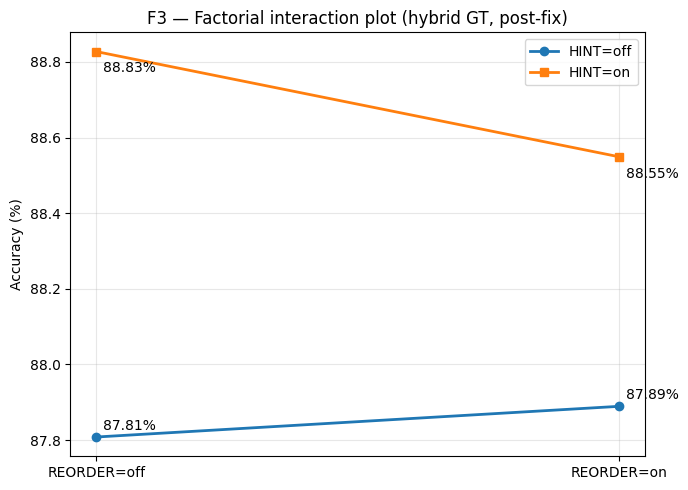

Saved: F3_factorial_postfix.png


In [7]:
acc_hybrid = {v: float(p_hybrid[f'{v}_correct'].astype(float).mean()) for v in lib.VARIANTS}

fig, ax = plt.subplots(figsize=(7, 5))
x_vals = ['REORDER=off', 'REORDER=on']
hint_off = [acc_hybrid['a0'] * 100, acc_hybrid['a1'] * 100]
hint_on  = [acc_hybrid['a2'] * 100, acc_hybrid['v_new'] * 100]
ax.plot(x_vals, hint_off, marker='o', label='HINT=off', linewidth=2)
ax.plot(x_vals, hint_on,  marker='s', label='HINT=on',  linewidth=2)
ax.set_ylabel('Accuracy (%)')
ax.set_title('F3 \u2014 Factorial interaction plot (hybrid GT, post-fix)')
ax.legend()
ax.grid(alpha=0.3)
for xi, (off, on) in enumerate(zip(hint_off, hint_on)):
    ax.annotate(f'{off:.2f}%', (xi, off), textcoords='offset points', xytext=(5, 5))
    ax.annotate(f'{on:.2f}%', (xi, on),  textcoords='offset points', xytext=(5, -15))
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / 'F3_factorial_postfix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: F3_factorial_postfix.png')

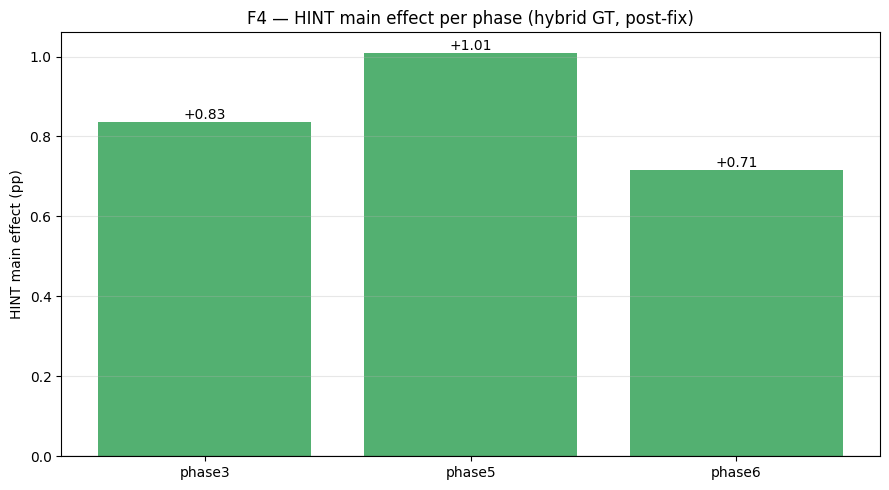

Saved: F4_hint_per_phase_postfix.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
phases_l = [p for p in phases if p in ppb_pivot.index]
hint_eff_pct = [hint_main_per_phase[ph] * 100 for ph in phases_l]
colors = ['#d7191c' if v < 0 else '#1a9641' for v in hint_eff_pct]
bars = ax.bar(phases_l, hint_eff_pct, color=colors, alpha=0.75)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('HINT main effect (pp)')
ax.set_title('F4 \u2014 HINT main effect per phase (hybrid GT, post-fix)')
for bar, val in zip(bars, hint_eff_pct):
    ax.annotate(f'{val:+.2f}', xy=(bar.get_x() + bar.get_width() / 2, val), ha='center', va='bottom' if val > 0 else 'top')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / 'F4_hint_per_phase_postfix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: F4_hint_per_phase_postfix.png')

## Cell 7 — Verification summary `[PASS/FAIL]`

In [9]:
checks = []

r_pp = e2b_hybrid['main_effect_reorder']['point_pp']
h_pp = e2b_hybrid['main_effect_hint']['point_pp']
i_pp = e2b_hybrid['interaction_reorder_x_hint']['point_pp']
e1_h_pp = e1_hybrid['v_new_minus_a0_pp']

checks.append(('hybrid GT universe = pairing universe',
               e1_hybrid['n'] == len(p_hybrid), f"n={e1_hybrid['n']} vs |p_hybrid|={len(p_hybrid)}"))
checks.append(('gt_hybrid covers 120 human + 2241 arbiter_v2',
               gt_hybrid['gt_source'].value_counts().to_dict() == {'arbiter_v2': 2241, 'human': 120},
               str(gt_hybrid['gt_source'].value_counts().to_dict())))
checks.append(('REORDER main \u2248 0 (sign-insensitive)',
               abs(r_pp) < 1.0, f'r={r_pp:+.2f}pp'))
checks.append(('HINT main direction preserved (> 0, matches T3 GT v2)',
               h_pp > 0, f'h={h_pp:+.2f}pp'))
checks.append(('INTERACTION small (|.| < 1.5 pp)',
               abs(i_pp) < 1.5, f'i={i_pp:+.2f}pp'))
checks.append(('E1 hybrid GT direction preserved (> 0)',
               e1_h_pp > 0, f'E1={e1_h_pp:+.2f}pp'))
checks.append(('\u03ba(A0, A1) > \u03ba(A0, V_new) (REORDER closer than HINT)',
               k_a0_a1 > k_a0_vn, f'\u0394\u03ba={k_a0_a1 - k_a0_vn:+.4f}'))
checks.append(('all variants in [0.65, 0.95] accuracy range',
               all(0.65 < acc_hybrid[v] < 0.95 for v in lib.VARIANTS),
               str({v: round(acc_hybrid[v], 4) for v in lib.VARIANTS})))
checks.append(('all per-phase HINT effects > 0 (positive on every phase)',
               all(eff > 0 for eff in hint_main_per_phase.values()),
               str({ph: f'{eff*100:+.2f}pp' for ph, eff in hint_main_per_phase.items()})))
checks.append(('all 3 phases present (phase3, phase5, phase6)',
               set(phases) == {'phase3', 'phase5', 'phase6'}, str(phases)))

print('=' * 80)
print('TN3 Post-fix Factorial Verification Summary')
print('=' * 80)
all_pass = True
for name, ok, info in checks:
    tag = '[PASS]' if ok else '[FAIL]'
    print(f'  {tag} {name:55s}  {info}')
    if not ok:
        all_pass = False
print('=' * 80)
print(f'[{"ALL PASS" if all_pass else "FAIL"}]')
print('=' * 80)

TN3 Post-fix Factorial Verification Summary
  [PASS] hybrid GT universe = pairing universe                    n=8637 vs |p_hybrid|=8637
  [PASS] gt_hybrid covers 120 human + 2241 arbiter_v2             {'arbiter_v2': 2241, 'human': 120}
  [PASS] REORDER main ≈ 0 (sign-insensitive)                      r=-0.03pp
  [PASS] HINT main direction preserved (> 0, matches T3 GT v2)    h=+0.72pp
  [PASS] INTERACTION small (|.| < 1.5 pp)                         i=-0.46pp
  [PASS] E1 hybrid GT direction preserved (> 0)                   E1=+0.74pp
  [PASS] κ(A0, A1) > κ(A0, V_new) (REORDER closer than HINT)      Δκ=+0.1684
  [PASS] all variants in [0.65, 0.95] accuracy range              {'a0': 0.8781, 'a1': 0.8789, 'a2': 0.8883, 'v_new': 0.8855}
  [PASS] all per-phase HINT effects > 0 (positive on every phase)  {'phase3': '+0.83pp', 'phase5': '+1.01pp', 'phase6': '+0.71pp'}
  [PASS] all 3 phases present (phase3, phase5, phase6)            ['phase3', 'phase5', 'phase6']
[ALL PASS]
